# SilverFit-KR Colab 버전: KLUE-BERT 시니어 안전 홈트 분류



## 목표

`klue/bert-base`를 fine-tuning해서 한국어 운동 설명 문장을 6개 유형으로 분류합니다.

- 근력
- 균형
- 관절가동성
- 유연성
- 유산소
- 호흡





```text
원본 운동 데이터 → 운동 단위로 train/validation 먼저 분리 → 각각 따로 문장 증강
```

따라서 validation에는 train에서 보지 못한 운동명이 들어갑니다.

## 0. Colab 실행 전 설정

Colab 상단 메뉴에서 먼저 설정하세요.

```text
런타임 → 런타임 유형 변경 → 하드웨어 가속기 → GPU
```

T4 GPU면 충분합니다.

In [1]:
# ============================================================
# 0. 라이브러리 설치 - Colab 호환 고정 버전
# ============================================================
# pandas/numpy가 너무 최신 버전으로 올라가면 Colab 기본 패키지와 충돌합니다.
# 그래서 Colab에서 안정적인 버전으로 고정합니다.

!pip install -q --upgrade --force-reinstall \
    "numpy==2.0.2" \
    "pandas==2.2.2"

# transformers/datasets 계열도 너무 최신/구버전 충돌을 피하기 위해 범위를 제한합니다.
!pip install -q --upgrade \
    "transformers>=4.44.0,<4.49.0" \
    "datasets>=2.20.0,<3.3.0" \
    "accelerate>=0.33.0,<1.2.0" \
    "evaluate>=0.4.2,<0.5.0" \
    "scikit-learn>=1.5.0,<1.7.0"

print("설치 완료. 이제 Colab 메뉴에서 [런타임] → [런타임 다시 시작]을 누른 뒤 처음부터 다시 실행하세요.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 21.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Import, seed 고정, 환경 확인

모델 학습 결과는 실행할 때마다 조금씩 달라질 수 있습니다.  
그래도 최대한 비슷한 결과가 나오도록 `SEED`를 고정합니다.

In [2]:
# ============================================================
# 1. 기본 import
# ============================================================

import os
import time
import json
import random
import zipfile
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import transformers
import datasets
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# ============================================================
# 2. seed 고정
# ============================================================
# random, numpy, torch의 랜덤성을 최대한 고정합니다.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# 3. 환경 확인
# ============================================================

print("torch version       :", torch.__version__)
print("transformers version:", transformers.__version__)
print("datasets version    :", datasets.__version__)
print("GPU available       :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name            :", torch.cuda.get_device_name(0))
else:
    print("GPU가 잡히지 않았습니다. Colab 런타임 유형을 GPU로 바꾸세요.")

torch version       : 2.10.0+cu128
transformers version: 4.48.3
datasets version    : 3.2.0
GPU available       : True
GPU name            : Tesla T4


## 2. 프로젝트 폴더 만들기

Colab에서는 파일이 `/content` 아래에 저장됩니다.  
학습 결과, 데이터, 보고서를 구분해서 저장하기 위해 폴더를 만듭니다.

In [3]:
# ============================================================
# 프로젝트 저장 경로
# ============================================================

PROJECT_DIR = Path("/content/silverfit_klue_bert_colab")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
REPORT_DIR = OUTPUT_DIR / "report"
MODEL_DIR = OUTPUT_DIR / "model"

for path in [PROJECT_DIR, DATA_DIR, OUTPUT_DIR, REPORT_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR   :", DATA_DIR)
print("OUTPUT_DIR :", OUTPUT_DIR)

PROJECT_DIR: /content/silverfit_klue_bert_colab
DATA_DIR   : /content/silverfit_klue_bert_colab/data
OUTPUT_DIR : /content/silverfit_klue_bert_colab/outputs


## 3. 원본 운동 데이터 생성

실제 서비스라면 전문가 검수 데이터, 병원 운동 처방 데이터, 공공 데이터 등을 사용해야 합니다.  
여기서는 과제 실행을 위해 작은 예시 데이터셋을 직접 만듭니다.

데이터의 기본 단위는 **문장 하나가 아니라 운동 하나**입니다.

각 운동에는 다음 정보가 들어갑니다.

- 운동 이름
- 운동 유형 라벨
- 사용 부위
- 목적
- 시니어 안전 주의사항

In [4]:
# ============================================================
# 원본 운동 데이터 만들기
# ============================================================
# 코드를 너무 길게 만들지 않기 위해 label별 운동 이름만 먼저 정의합니다.
# 그 다음 label에 맞는 기본 목적/주의사항을 붙여서 원본 데이터를 만듭니다.

exercise_names = {
    "근력": ["의자 스쿼트", "벽 밀기", "앉아서 무릎 펴기", "발뒤꿈치 들기", "물병 컬", "수건 당기기", "앉아서 팔 밀기", "엉덩이 조이기"],
    "균형": ["한 발 서기", "일자 걷기", "옆으로 걷기", "뒤꿈치 발끝 걷기", "체중 좌우 이동", "벽 앞 균형 버티기", "발끝 터치 균형", "앉았다 일어나 중심 잡기"],
    "관절가동성": ["목 좌우 돌리기", "어깨 원 그리기", "손목 돌리기", "발목 원 그리기", "무릎 굽혔다 펴기", "골반 앞뒤 기울이기", "손가락 펴고 쥐기", "앉아서 몸통 회전"],
    "유연성": ["종아리 스트레칭", "허벅지 뒤 스트레칭", "가슴 열기 스트레칭", "옆구리 늘리기", "목 옆 늘리기", "엉덩이 스트레칭", "손목 굽힘 스트레칭", "허리 숙이기 스트레칭"],
    "유산소": ["제자리 걷기", "팔 흔들며 걷기", "앉아서 발 구르기", "실내 천천히 걷기", "낮은 스텝 터치", "의자 옆 걷기", "천천히 무릎 들기", "리듬 걷기"],
    "호흡": ["복식호흡", "입술 오므리기 호흡", "4초 들숨 6초 날숨", "앉아서 깊은 호흡", "어깨 이완 호흡", "갈비뼈 확장 호흡", "코로 들이마시고 입으로 내쉬기", "명상 호흡"],
}

# label별 기본 설명입니다.
# 이 설명은 문장 증강 때 함께 사용됩니다.
label_profile = {
    "근력": {"body": "근육", "goal": "근력을 높이고 일상 동작을 안정적으로 만든다", "safety": "통증이 있으면 반복 횟수와 범위를 줄인다"},
    "균형": {"body": "전신 균형", "goal": "낙상 위험을 줄이고 중심 잡는 능력을 높인다", "safety": "반드시 벽이나 의자를 가까이 두고 수행한다"},
    "관절가동성": {"body": "관절", "goal": "관절의 움직임을 부드럽게 만들고 뻣뻣함을 줄인다", "safety": "아픈 각도까지 억지로 움직이지 않는다"},
    "유연성": {"body": "근육과 인대", "goal": "짧아진 근육을 천천히 늘리고 긴장을 완화한다", "safety": "반동을 주지 않고 편안한 범위에서 유지한다"},
    "유산소": {"body": "심폐와 전신", "goal": "심박수를 가볍게 올리고 활동량을 늘린다", "safety": "숨이 너무 차면 즉시 속도를 낮추거나 쉰다"},
    "호흡": {"body": "호흡", "goal": "호흡 리듬을 안정시키고 긴장을 낮춘다", "safety": "어지러우면 호흡 깊이를 줄이고 잠시 쉰다"},
}

rows = []
exercise_id = 0

for label, names in exercise_names.items():
    for name in names:
        rows.append({
            "exercise_id": f"EX{exercise_id:03d}",
            "exercise_name": name,
            "label": label,
            "body_part": label_profile[label]["body"],
            "goal": label_profile[label]["goal"],
            "safety": label_profile[label]["safety"],
        })
        exercise_id += 1

raw_df = pd.DataFrame(rows)
raw_df.to_csv(DATA_DIR / "silverfit_raw_exercises.csv", index=False, encoding="utf-8-sig")

print("원본 운동 개수:", len(raw_df))
display(raw_df.head(12))

원본 운동 개수: 48


,exercise_id,exercise_name,label,body_part,goal,safety
0,EX000,의자 스쿼트,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
1,EX001,벽 밀기,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
2,EX002,앉아서 무릎 펴기,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
3,EX003,발뒤꿈치 들기,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
4,EX004,물병 컬,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
5,EX005,수건 당기기,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
6,EX006,앉아서 팔 밀기,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
7,EX007,엉덩이 조이기,근력,근육,근력을 높이고 일상 동작을 안정적으로 만든다,통증이 있으면 반복 횟수와 범위를 줄인다
8,EX008,한 발 서기,균형,전신 균형,낙상 위험을 줄이고 중심 잡는 능력을 높인다,반드시 벽이나 의자를 가까이 두고 수행한다
9,EX009,일자 걷기,균형,전신 균형,낙상 위험을 줄이고 중심 잡는 능력을 높인다,반드시 벽이나 의자를 가까이 두고 수행한다


## 4. 라벨을 숫자로 변환

모델은 `근력`, `균형` 같은 글자를 정답으로 직접 쓰지 않습니다.  
그래서 각 라벨을 숫자로 바꿉니다.

In [5]:
# ============================================================
# label 문자열을 숫자로 변환
# ============================================================

label_list = sorted(raw_df["label"].unique().tolist())
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

raw_df["label_id"] = raw_df["label"].map(label2id)

print("label_list:", label_list)
print("label2id:", label2id)
print("id2label:", id2label)

with open(DATA_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({"label_list": label_list, "label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)

label_list: ['관절가동성', '균형', '근력', '유산소', '유연성', '호흡']
label2id: {'관절가동성': 0, '균형': 1, '근력': 2, '유산소': 3, '유연성': 4, '호흡': 5}
id2label: {0: '관절가동성', 1: '균형', 2: '근력', 3: '유산소', 4: '유연성', 5: '호흡'}


## 5. 운동 단위 train/validation 분리

이 셀이 가장 중요합니다.

문장으로 증강하기 전에 먼저 **운동 단위**로 train과 validation을 나눕니다.  
그래야 같은 운동이 train과 validation에 동시에 들어가는 문제를 막을 수 있습니다.

In [6]:
# ============================================================
# 운동 단위 train/validation split
# ============================================================

train_raw_df, valid_raw_df = train_test_split(
    raw_df,
    test_size=0.20,
    random_state=SEED,
    stratify=raw_df["label_id"],
)

train_raw_df = train_raw_df.reset_index(drop=True)
valid_raw_df = valid_raw_df.reset_index(drop=True)

# train/validation에 같은 운동 ID가 들어갔는지 확인합니다.
train_ids = set(train_raw_df["exercise_id"])
valid_ids = set(valid_raw_df["exercise_id"])
overlap_ids = train_ids.intersection(valid_ids)

print("train 원본 운동 개수:", len(train_raw_df))
print("valid 원본 운동 개수:", len(valid_raw_df))
print("운동 ID 겹침 개수:", len(overlap_ids))

assert len(overlap_ids) == 0, "데이터 누수 발생: train과 validation에 같은 운동이 있습니다."

display(train_raw_df["label"].value_counts().sort_index())
display(valid_raw_df["label"].value_counts().sort_index())

train 원본 운동 개수: 38
valid 원본 운동 개수: 10
운동 ID 겹침 개수: 0


,count
label,
관절가동성,7
균형,7
근력,6
유산소,6
유연성,6
호흡,6


,count
label,
관절가동성,1
균형,1
근력,2
유산소,2
유연성,2
호흡,2


## 6. 문장 증강

원본 운동 하나를 여러 개의 학습 문장으로 바꿉니다.

예를 들어 `의자 스쿼트` 하나에서 여러 문장을 만듭니다.

- 의자 스쿼트는 근력을 높이는 운동입니다.
- 시니어가 의자 스쿼트를 할 때는 통증이 있으면 범위를 줄여야 합니다.
- 이 운동은 근력 유형으로 분류할 수 있습니다.

중요한 점은 train 원본과 validation 원본을 **각각 따로 증강**한다는 것입니다.

In [7]:
# ============================================================
# 문장 증강 함수
# ============================================================

def make_augmented_sentences(df: pd.DataFrame) -> pd.DataFrame:
    """
    원본 운동 데이터프레임을 받아서 문장 단위 학습 데이터로 바꿉니다.

    입력:
        df: 운동 단위 DataFrame

    출력:
        한 운동당 5개 문장으로 늘어난 DataFrame
    """
    augmented_rows = []

    for _, row in df.iterrows():
        exercise_id = row["exercise_id"]
        name = row["exercise_name"]
        label = row["label"]
        label_id = int(row["label_id"])
        body = row["body_part"]
        goal = row["goal"]
        safety = row["safety"]

        # 한 운동당 5개 문장을 만듭니다.
        # 일부 문장에는 label명을 직접 넣고,
        # 일부 문장에는 목적/주의사항을 넣어 문맥으로 분류하게 합니다.
        sentences = [
            f"{name}는 {body}을 사용하는 {label} 운동이다. {goal}.",
            f"시니어가 {name}를 할 때는 {safety}.",
            f"{name} 동작은 {goal}는 목적이 있어 {label} 유형으로 볼 수 있다.",
            f"집에서 {name}를 천천히 수행하면 {body}의 기능을 안전하게 자극할 수 있다.",
            f"이 운동의 핵심은 {goal}이며, 주의사항은 {safety}.",
        ]

        for view_id, text in enumerate(sentences):
            augmented_rows.append({
                "exercise_id": exercise_id,
                "exercise_name": name,
                "view_id": view_id,
                "text": text,
                "label": label,
                "label_id": label_id,
            })

    return pd.DataFrame(augmented_rows)

train_df = make_augmented_sentences(train_raw_df)
valid_df = make_augmented_sentences(valid_raw_df)

train_df.to_csv(DATA_DIR / "train_augmented.csv", index=False, encoding="utf-8-sig")
valid_df.to_csv(DATA_DIR / "validation_augmented.csv", index=False, encoding="utf-8-sig")

print("train 문장 개수:", len(train_df))
print("valid 문장 개수:", len(valid_df))
display(train_df.head(10))

train 문장 개수: 190
valid 문장 개수: 50


,exercise_id,exercise_name,view_id,text,label,label_id
0,EX028,목 옆 늘리기,0,목 옆 늘리기는 근육과 인대을 사용하는 유연성 운동이다. 짧아진 근육을 천천히 늘리...,유연성,4
1,EX028,목 옆 늘리기,1,시니어가 목 옆 늘리기를 할 때는 반동을 주지 않고 편안한 범위에서 유지한다.,유연성,4
2,EX028,목 옆 늘리기,2,목 옆 늘리기 동작은 짧아진 근육을 천천히 늘리고 긴장을 완화한다는 목적이 있어 유...,유연성,4
3,EX028,목 옆 늘리기,3,집에서 목 옆 늘리기를 천천히 수행하면 근육과 인대의 기능을 안전하게 자극할 수 있다.,유연성,4
4,EX028,목 옆 늘리기,4,"이 운동의 핵심은 짧아진 근육을 천천히 늘리고 긴장을 완화한다이며, 주의사항은 반동...",유연성,4
5,EX032,제자리 걷기,0,제자리 걷기는 심폐와 전신을 사용하는 유산소 운동이다. 심박수를 가볍게 올리고 활동...,유산소,3
6,EX032,제자리 걷기,1,시니어가 제자리 걷기를 할 때는 숨이 너무 차면 즉시 속도를 낮추거나 쉰다.,유산소,3
7,EX032,제자리 걷기,2,제자리 걷기 동작은 심박수를 가볍게 올리고 활동량을 늘린다는 목적이 있어 유산소 유...,유산소,3
8,EX032,제자리 걷기,3,집에서 제자리 걷기를 천천히 수행하면 심폐와 전신의 기능을 안전하게 자극할 수 있다.,유산소,3
9,EX032,제자리 걷기,4,"이 운동의 핵심은 심박수를 가볍게 올리고 활동량을 늘린다이며, 주의사항은 숨이 너무...",유산소,3


## 7. 증강 후 데이터 누수 재확인

문장 증강 후에도 train과 validation의 운동 ID가 겹치면 안 됩니다.

In [8]:
# ============================================================
# 증강 후 데이터 누수 확인
# ============================================================

train_aug_ids = set(train_df["exercise_id"])
valid_aug_ids = set(valid_df["exercise_id"])
overlap_after_aug = train_aug_ids.intersection(valid_aug_ids)

print("증강 후 운동 ID 겹침 개수:", len(overlap_after_aug))
assert len(overlap_after_aug) == 0, "증강 후 데이터 누수가 발생했습니다."

print("\ntrain 문장 예시")
for t in train_df["text"].head(5):
    print("-", t)

print("\nvalidation 문장 예시")
for t in valid_df["text"].head(5):
    print("-", t)

증강 후 운동 ID 겹침 개수: 0

train 문장 예시
- 목 옆 늘리기는 근육과 인대을 사용하는 유연성 운동이다. 짧아진 근육을 천천히 늘리고 긴장을 완화한다.
- 시니어가 목 옆 늘리기를 할 때는 반동을 주지 않고 편안한 범위에서 유지한다.
- 목 옆 늘리기 동작은 짧아진 근육을 천천히 늘리고 긴장을 완화한다는 목적이 있어 유연성 유형으로 볼 수 있다.
- 집에서 목 옆 늘리기를 천천히 수행하면 근육과 인대의 기능을 안전하게 자극할 수 있다.
- 이 운동의 핵심은 짧아진 근육을 천천히 늘리고 긴장을 완화한다이며, 주의사항은 반동을 주지 않고 편안한 범위에서 유지한다.

validation 문장 예시
- 팔 흔들며 걷기는 심폐와 전신을 사용하는 유산소 운동이다. 심박수를 가볍게 올리고 활동량을 늘린다.
- 시니어가 팔 흔들며 걷기를 할 때는 숨이 너무 차면 즉시 속도를 낮추거나 쉰다.
- 팔 흔들며 걷기 동작은 심박수를 가볍게 올리고 활동량을 늘린다는 목적이 있어 유산소 유형으로 볼 수 있다.
- 집에서 팔 흔들며 걷기를 천천히 수행하면 심폐와 전신의 기능을 안전하게 자극할 수 있다.
- 이 운동의 핵심은 심박수를 가볍게 올리고 활동량을 늘린다이며, 주의사항은 숨이 너무 차면 즉시 속도를 낮추거나 쉰다.


## 8. Hugging Face Dataset 변환

`Trainer`는 pandas DataFrame보다 Hugging Face `Dataset` 형식을 쓰면 편합니다.

정답 라벨 컬럼 이름은 `labels`로 맞춥니다.

In [9]:
# ============================================================
# pandas DataFrame → Hugging Face Dataset
# ============================================================

train_for_hf = train_df[["text", "label_id"]].rename(columns={"label_id": "labels"})
valid_for_hf = valid_df[["text", "label_id"]].rename(columns={"label_id": "labels"})

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_for_hf, preserve_index=False),
    "validation": Dataset.from_pandas(valid_for_hf, preserve_index=False),
})

print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 190
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 50
    })
})
{'text': '목 옆 늘리기는 근육과 인대을 사용하는 유연성 운동이다. 짧아진 근육을 천천히 늘리고 긴장을 완화한다.', 'labels': 4}


## 9. Tokenizer 불러오기

`klue/bert-base` tokenizer는 한국어 문장을 BERT가 이해할 수 있는 토큰 ID로 바꿉니다.

In [10]:
# ============================================================
# Tokenizer 설정
# ============================================================

MODEL_NAME = "klue/bert-base"
NUM_LABELS = len(label_list)
MAX_LENGTH = 96

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_text = train_df.loc[0, "text"]
sample_encoded = tokenizer(sample_text)

print("샘플 문장:", sample_text)
print("토큰 ID 일부:", sample_encoded["input_ids"][:20])
print("토큰 개수:", len(sample_encoded["input_ids"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

샘플 문장: 목 옆 늘리기는 근육과 인대을 사용하는 유연성 운동이다. 짧아진 근육을 천천히 늘리고 긴장을 완화한다.
토큰 ID 일부: [2, 1079, 1438, 6245, 2015, 2259, 6608, 2145, 18052, 2069, 3704, 2205, 2259, 7668, 2047, 3815, 28674, 18, 1599, 2227]
토큰 개수: 32


## 10. 토큰화: 일반 padding과 dynamic padding

두 가지 방식을 비교합니다.

### 일반 fixed padding
모든 문장을 `MAX_LENGTH` 길이로 맞춥니다.

### dynamic padding + bucketing
각 batch 안에서 가장 긴 문장에 맞춰 padding합니다.  
`group_by_length=True`를 쓰면 길이가 비슷한 문장끼리 묶어 padding 낭비를 줄입니다.

In [11]:
# ============================================================
# 토큰화 함수 2개
# ============================================================

def tokenize_fixed_padding(batch):
    # padding="max_length": 모든 문장을 MAX_LENGTH 길이로 맞춥니다.
    # 짧은 문장은 [PAD]로 채우고, 긴 문장은 MAX_LENGTH에서 자릅니다.
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)


def tokenize_dynamic_padding(batch):
    # 여기서는 padding을 하지 않습니다.
    # 나중에 DataCollatorWithPadding이 batch 단위로 padding합니다.
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

fixed_tokenized_dataset = dataset.map(tokenize_fixed_padding, batched=True, remove_columns=["text"])
dynamic_tokenized_dataset = dataset.map(tokenize_dynamic_padding, batched=True, remove_columns=["text"])

print("fixed input length  :", len(fixed_tokenized_dataset["train"][0]["input_ids"]))
print("dynamic input length:", len(dynamic_tokenized_dataset["train"][0]["input_ids"]))

Map:   0%|          | 0/190 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/190 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

fixed input length  : 96
dynamic input length: 32


## 11. Data Collator 준비

Data Collator는 여러 샘플을 하나의 batch로 묶습니다.

- fixed padding 데이터는 이미 길이가 맞춰져 있습니다.
- dynamic padding 데이터는 batch를 만들 때 padding해야 합니다.

In [12]:
# ============================================================
# Data Collator
# ============================================================

# dynamic padding용 collator입니다.
# batch 안에서 가장 긴 문장 길이에 맞춰 자동으로 padding합니다.
dynamic_data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# fixed padding은 이미 길이가 같으므로 기본 collator를 써도 됩니다.
fixed_data_collator = None

## 12. 평가 함수

분류 모델 평가에는 accuracy와 macro F1을 사용합니다.

- accuracy: 전체 중 맞힌 비율
- macro F1: 라벨별 F1을 평균낸 값

In [13]:
# ============================================================
# 평가 지표 함수
# ============================================================

def compute_metrics(eval_pred):
    # eval_pred는 Trainer가 넘겨주는 평가 결과입니다.
    # predictions: 모델이 출력한 logits
    # label_ids: 실제 정답 라벨
    logits, labels = eval_pred

    # logits에서 가장 큰 값의 위치가 예측 라벨입니다.
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

## 13. TrainingArguments 호환 함수

`transformers` 버전에 따라 `evaluation_strategy`, `eval_strategy`, `group_by_length` 지원 여부가 다를 수 있습니다.  
아래 함수는 현재 버전이 지원하는 인자만 넣어서 오류를 줄입니다.

In [14]:
# ============================================================
# TrainingArguments를 안전하게 만드는 함수
# ============================================================

def make_training_args(output_dir: Path, run_name: str, group_by_length: bool):
    params = inspect.signature(TrainingArguments.__init__).parameters

    args = {
        "output_dir": str(output_dir),
        "run_name": run_name,
        "num_train_epochs": 5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.06,
        "logging_steps": 10,
        "save_strategy": "no",
        "report_to": "none",
        "fp16": torch.cuda.is_available(),
        "seed": SEED,
        "data_seed": SEED,
    }

    # 버전에 따라 평가 전략 인자 이름이 다를 수 있습니다.
    if "evaluation_strategy" in params:
        args["evaluation_strategy"] = "epoch"
    elif "eval_strategy" in params:
        args["eval_strategy"] = "epoch"

    # group_by_length는 bucketing에 필요한 옵션입니다.
    # 지원하는 버전에서만 넣습니다.
    if "group_by_length" in params:
        args["group_by_length"] = group_by_length
    elif group_by_length:
        print("현재 transformers 버전은 group_by_length를 지원하지 않습니다. dynamic padding으로만 진행합니다.")

    # 현재 버전에서 받지 않는 인자는 제거합니다.
    safe_args = {k: v for k, v in args.items() if k in params}
    return TrainingArguments(**safe_args)

## 14. 모델과 Trainer 생성 함수

`Trainer`도 버전에 따라 `tokenizer` 인자를 받거나, `processing_class` 인자를 받습니다.  
아래 함수는 현재 설치된 버전에 맞춰 자동 처리합니다.

In [15]:
# ============================================================
# 새 모델 생성 함수
# ============================================================

def create_fresh_model():
    # 실험마다 새 모델을 불러와야 공정하게 비교할 수 있습니다.
    # 같은 모델로 두 번 학습하면 두 번째 실험은 이미 학습된 상태에서 시작하기 때문입니다.
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label={int(k): v for k, v in id2label.items()},
        label2id=label2id,
    )


# ============================================================
# Trainer 생성 함수
# ============================================================

def build_trainer(run_name: str, tokenized_dataset: DatasetDict, data_collator, group_by_length: bool):
    model = create_fresh_model()
    args = make_training_args(OUTPUT_DIR / run_name, run_name, group_by_length)

    trainer_params = inspect.signature(Trainer.__init__).parameters

    trainer_kwargs = {
        "model": model,
        "args": args,
        "train_dataset": tokenized_dataset["train"],
        "eval_dataset": tokenized_dataset["validation"],
        "compute_metrics": compute_metrics,
    }

    if data_collator is not None:
        trainer_kwargs["data_collator"] = data_collator

    # transformers 버전 호환 처리
    if "processing_class" in trainer_params:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_params:
        trainer_kwargs["tokenizer"] = tokenizer

    safe_kwargs = {k: v for k, v in trainer_kwargs.items() if k in trainer_params}
    return Trainer(**safe_kwargs)

## 15. 실험 1: 일반 fixed padding 학습

모든 문장을 `MAX_LENGTH` 길이로 맞춘 상태에서 학습합니다.

In [16]:
# ============================================================
# 실험 1: 일반 fixed padding
# ============================================================

normal_trainer = build_trainer(
    run_name="normal_fixed_padding",
    tokenized_dataset=fixed_tokenized_dataset,
    data_collator=fixed_data_collator,
    group_by_length=False,
)

start_time = time.time()
normal_trainer.train()
normal_train_time = time.time() - start_time

normal_metrics = normal_trainer.evaluate()
normal_metrics["train_time_sec"] = round(normal_train_time, 2)

print(json.dumps(normal_metrics, indent=2, ensure_ascii=False))

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.712200,1.443252,0.700000,0.640959
2,1.317600,0.886196,0.960000,0.958393
3,0.873900,0.516560,0.960000,0.966330
4,0.535300,0.345168,0.960000,0.966330
5,0.319200,0.293728,0.980000,0.983292


{
  "eval_loss": 0.2937280237674713,
  "eval_accuracy": 0.98,
  "eval_macro_f1": 0.9832915622389305,
  "eval_runtime": 0.1417,
  "eval_samples_per_second": 352.866,
  "eval_steps_per_second": 14.115,
  "epoch": 5.0,
  "train_time_sec": 14.71
}


## 16. 실험 2: dynamic padding + bucketing 학습

배치 단위로 필요한 만큼만 padding합니다.  
지원되는 환경에서는 `group_by_length=True`로 길이가 비슷한 문장끼리 묶습니다.

In [17]:
# ============================================================
# 실험 2: dynamic padding + bucketing
# ============================================================

bucket_trainer = build_trainer(
    run_name="bucketing_dynamic_padding",
    tokenized_dataset=dynamic_tokenized_dataset,
    data_collator=dynamic_data_collator,
    group_by_length=True,
)

start_time = time.time()
bucket_trainer.train()
bucket_train_time = time.time() - start_time

bucket_metrics = bucket_trainer.evaluate()
bucket_metrics["train_time_sec"] = round(bucket_train_time, 2)

print(json.dumps(bucket_metrics, indent=2, ensure_ascii=False))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.753800,1.485352,0.640000,0.619961
2,1.381800,1.013682,0.900000,0.886364
3,0.993800,0.633452,0.960000,0.958393
4,0.693000,0.470459,0.960000,0.958393
5,0.443300,0.400151,0.960000,0.958393


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

{
  "eval_loss": 0.40015870332717896,
  "eval_accuracy": 0.96,
  "eval_macro_f1": 0.9583934583934584,
  "eval_runtime": 0.0415,
  "eval_samples_per_second": 1206.258,
  "eval_steps_per_second": 48.25,
  "epoch": 5.0,
  "train_time_sec": 11.3
}


## 17. 결과 비교

일반 padding과 bucketing의 성능, 학습 시간을 비교합니다.

데이터가 작으면 속도 차이가 작게 나올 수 있습니다.  
데이터가 커지고 문장 길이 차이가 커질수록 bucketing 효과가 커집니다.

In [18]:
# ============================================================
# 결과 비교표 생성
# ============================================================

comparison_df = pd.DataFrame([
    {
        "experiment": "normal_fixed_padding",
        "eval_accuracy": normal_metrics.get("eval_accuracy"),
        "eval_macro_f1": normal_metrics.get("eval_macro_f1"),
        "train_time_sec": normal_metrics.get("train_time_sec"),
    },
    {
        "experiment": "bucketing_dynamic_padding",
        "eval_accuracy": bucket_metrics.get("eval_accuracy"),
        "eval_macro_f1": bucket_metrics.get("eval_macro_f1"),
        "train_time_sec": bucket_metrics.get("train_time_sec"),
    },
])

normal_time = comparison_df.loc[comparison_df["experiment"] == "normal_fixed_padding", "train_time_sec"].iloc[0]
bucket_time = comparison_df.loc[comparison_df["experiment"] == "bucketing_dynamic_padding", "train_time_sec"].iloc[0]

if normal_time > 0:
    speedup = round((normal_time - bucket_time) / normal_time * 100, 2)
else:
    speedup = 0

comparison_df["speedup_vs_normal_percent"] = [0, speedup]

display(comparison_df)

# 결과 저장
comparison_df.to_json(REPORT_DIR / "bucketing_comparison.json", orient="records", force_ascii=False, indent=2)
with open(REPORT_DIR / "normal_metrics.json", "w", encoding="utf-8") as f:
    json.dump(normal_metrics, f, ensure_ascii=False, indent=2)
with open(REPORT_DIR / "bucketing_metrics.json", "w", encoding="utf-8") as f:
    json.dump(bucket_metrics, f, ensure_ascii=False, indent=2)

,experiment,eval_accuracy,eval_macro_f1,train_time_sec,speedup_vs_normal_percent
0,normal_fixed_padding,0.98,0.983292,14.71,0.00
1,bucketing_dynamic_padding,0.96,0.958393,11.30,23.18


## 18. 실제 문장 예측 테스트

학습된 모델로 새로운 문장을 분류해봅니다.

In [19]:
# ============================================================
# 예측 함수
# ============================================================

def predict_exercise_type(text: str, trainer: Trainer = bucket_trainer):
    # 평가 모드로 전환합니다.
    trainer.model.eval()

    # 입력 문장을 토큰 ID로 변환합니다.
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)

    # 모델이 올라간 장치와 같은 장치로 입력을 옮깁니다.
    device = trainer.model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 예측에서는 gradient가 필요 없습니다.
    with torch.no_grad():
        outputs = trainer.model(**inputs)

    probs = torch.softmax(outputs.logits[0], dim=-1).detach().cpu().numpy()
    pred_id = int(np.argmax(probs))

    return {
        "text": text,
        "predicted_label": id2label[pred_id],
        "confidence": round(float(probs[pred_id]), 4),
        "probabilities": {id2label[i]: round(float(probs[i]), 4) for i in range(len(probs))},
    }

sample_sentences = [
    "의자를 잡고 한 발로 서서 낙상을 예방하는 중심 잡기 운동입니다.",
    "가벼운 물병을 들고 팔을 굽혔다 펴며 근육을 강화합니다.",
    "코로 천천히 들이마시고 입으로 길게 내쉬면서 호흡을 안정시킵니다.",
    "벽을 짚고 종아리 뒤쪽을 천천히 늘려주는 스트레칭입니다.",
]

for s in sample_sentences:
    print(json.dumps(predict_exercise_type(s), ensure_ascii=False, indent=2))
    print("-" * 80)

{
  "text": "의자를 잡고 한 발로 서서 낙상을 예방하는 중심 잡기 운동입니다.",
  "predicted_label": "균형",
  "confidence": 0.3513,
  "probabilities": {
    "관절가동성": 0.1778,
    "균형": 0.3513,
    "근력": 0.1354,
    "유산소": 0.0902,
    "유연성": 0.0831,
    "호흡": 0.1622
  }
}
--------------------------------------------------------------------------------
{
  "text": "가벼운 물병을 들고 팔을 굽혔다 펴며 근육을 강화합니다.",
  "predicted_label": "근력",
  "confidence": 0.2253,
  "probabilities": {
    "관절가동성": 0.1724,
    "균형": 0.1527,
    "근력": 0.2253,
    "유산소": 0.1704,
    "유연성": 0.1761,
    "호흡": 0.1031
  }
}
--------------------------------------------------------------------------------
{
  "text": "코로 천천히 들이마시고 입으로 길게 내쉬면서 호흡을 안정시킵니다.",
  "predicted_label": "호흡",
  "confidence": 0.5888,
  "probabilities": {
    "관절가동성": 0.0675,
    "균형": 0.0707,
    "근력": 0.0977,
    "유산소": 0.1236,
    "유연성": 0.0516,
    "호흡": 0.5888
  }
}
--------------------------------------------------------------------------------
{
  "text": "벽을 짚고 종아리 뒤쪽을 천천히 늘려주는 

# SilverFit Pose Analyzer - 사람 운동 자세 사진 판단 Colab 버전

이 노트북은 **사람이 운동하는 사진 1장**을 업로드하면 다음을 자동으로 분석합니다.

1. MediaPipe Pose로 사람의 관절 좌표를 추출합니다.
2. 어깨, 팔꿈치, 고관절, 무릎, 발목 좌표를 이용해 주요 관절 각도를 계산합니다.
3. 사진 속 자세가 `스쿼트`, `런지`, `플랭크`, `푸시업`, `팔 들기`, `무릎 들기`, `기본 서기/기타` 중 어디에 가까운지 판단합니다.
4. 시니어 홈트 관점에서 위험 요소를 간단히 평가합니다.
5. 관절선이 그려진 결과 이미지를 저장합니다.

> 현재 버전은 **데이터셋 학습 모델이 아니라 규칙 기반 MVP**입니다.  
> 과제/프로토타입 제출용으로는 “이미지에서 관절 좌표를 뽑고, 각도 기반으로 자세를 해석했다”는 구조를 보여주기에 적합합니다.

---

## 권장 실행 환경

- Google Colab
- 런타임 유형: CPU도 가능하지만, 가능하면 GPU 선택
- 메뉴: `런타임 → 런타임 유형 변경 → 하드웨어 가속기 GPU`

---

## 중요한 한계

- 사진 속 사람이 너무 작거나, 팔/다리가 가려져 있으면 정확도가 떨어집니다.
- 정면 사진과 측면 사진에서 각도 해석이 달라질 수 있습니다.
- 의료 진단이 아니라 **운동 자세 보조 분석**입니다.

In [20]:
# ============================================================
# 0. 라이브러리 설치
# ============================================================
# Colab은 기본 패키지 버전이 자주 바뀝니다.
# MediaPipe는 numpy 최신 버전과 충돌하는 경우가 있어 안정적인 버전으로 고정합니다.
# 이 셀은 Colab에서 처음 1번만 실행하면 됩니다.

!pip install -q --upgrade --force-reinstall "numpy==1.26.4" "pandas==2.2.2"
!pip install -q --upgrade "mediapipe==0.10.14" "opencv-python-headless==4.10.0.84" "matplotlib>=3.8,<3.10" "pillow"

print("설치 완료")
print("중요: 설치 직후에는 Colab 메뉴에서 [런타임] → [런타임 다시 시작]을 누른 뒤, 이 노트북을 처음부터 다시 실행하세요.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 74.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which 

## 1. import, 기본 설정

설치 후 런타임을 다시 시작했다면 여기부터 순서대로 실행하면 됩니다.

In [21]:
# ============================================================
# 1. import, 기본 설정
# ============================================================

import os
import math
import json
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import mediapipe as mp

# Colab 파일 업로드/다운로드용입니다.
from google.colab import files

# 결과 저장 폴더를 만듭니다.
PROJECT_DIR = Path("/content/silverfit_pose_project")
OUTPUT_DIR = PROJECT_DIR / "outputs"
ANNOTATED_DIR = OUTPUT_DIR / "annotated_images"

for d in [PROJECT_DIR, OUTPUT_DIR, ANNOTATED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("프로젝트 폴더:", PROJECT_DIR)
print("결과 저장 폴더:", OUTPUT_DIR)
print("MediaPipe version:", mp.__version__)

# MediaPipe의 기존 Pose API가 정상적으로 있는지 확인합니다.
# 사용자가 이전에 'mediapipe has no attribute solutions' 오류를 겪을 수 있어 방어적으로 체크합니다.
if not hasattr(mp, "solutions"):
    raise RuntimeError("현재 mediapipe 설치에 solutions 모듈이 없습니다. 런타임을 다시 시작한 뒤 0번 설치 셀부터 다시 실행하세요.")


프로젝트 폴더: /content/silverfit_pose_project
결과 저장 폴더: /content/silverfit_pose_project/outputs
MediaPipe version: 0.10.14


## 2. MediaPipe Pose 준비

MediaPipe Pose는 사람의 몸에서 주요 관절 좌표를 추정합니다.  
이 노트북에서는 사진 1장을 분석하는 `static_image_mode=True` 설정을 사용합니다.

In [22]:
# ============================================================
# 2. MediaPipe Pose 준비
# ============================================================

# MediaPipe Pose 관련 도구를 불러옵니다.
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Pose 객체를 생성합니다.
# static_image_mode=True:
#   - 영상이 아니라 사진 1장씩 분석할 때 사용합니다.
# model_complexity=2:
#   - 0, 1, 2 중 선택 가능합니다.
#   - 2가 가장 무겁지만 정확도가 상대적으로 좋습니다.
# min_detection_confidence=0.5:
#   - 사람 포즈로 인정할 최소 신뢰도입니다.
pose_detector = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    min_detection_confidence=0.5,
)

print("MediaPipe Pose 준비 완료")

MediaPipe Pose 준비 완료


## 3. 이미지 업로드

운동 자세 사진을 업로드합니다.  
사진은 가능하면 다음 조건이 좋습니다.

- 전신이 보이는 사진
- 팔과 다리가 가려지지 않은 사진
- 사람이 너무 작게 나오지 않는 사진
- 정면 또는 측면 중 하나가 명확한 사진

Saving 다운로드 (1).jpg to 다운로드 (1).jpg
업로드한 이미지: 다운로드 (1).jpg


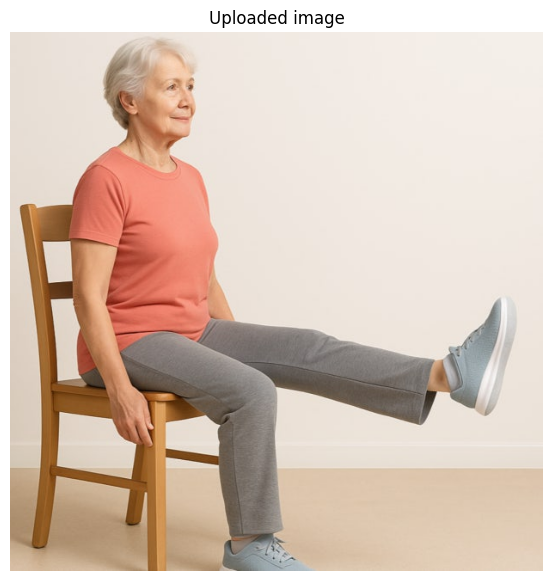

In [23]:
# ============================================================
# 3. 이미지 업로드
# ============================================================

uploaded = files.upload()

# 업로드된 파일 중 첫 번째 파일을 사용합니다.
# 여러 장을 한 번에 분석하는 코드는 뒤쪽에 별도로 있습니다.
image_path = list(uploaded.keys())[0]
print("업로드한 이미지:", image_path)

# OpenCV는 이미지를 BGR 순서로 읽습니다.
# 화면 출력과 MediaPipe 처리를 위해 RGB로 변환합니다.
bgr_image = cv2.imread(image_path)
if bgr_image is None:
    raise ValueError("이미지를 읽지 못했습니다. JPG/PNG 파일인지 확인하세요.")

rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 7))
plt.imshow(rgb_image)
plt.axis("off")
plt.title("Uploaded image")
plt.show()

## 4. 관절 좌표 추출 함수

MediaPipe는 각 관절을 번호로 제공합니다.  
분석하기 쉽게 `LEFT_SHOULDER`, `RIGHT_KNEE` 같은 이름으로 바꿔서 저장합니다.

좌표 의미:

- `x`: 이미지 가로 방향 위치. 왼쪽 0, 오른쪽 1
- `y`: 이미지 세로 방향 위치. 위쪽 0, 아래쪽 1
- `z`: 깊이 방향 값. 카메라 기준 상대값
- `visibility`: 해당 관절이 사진에서 잘 보이는지에 대한 값. 1에 가까울수록 잘 보임

In [24]:
# ============================================================
# 4. 관절 좌표 추출 함수
# ============================================================

def extract_pose_landmarks(rgb_image, detector):
    """
    RGB 이미지를 입력받아 MediaPipe Pose 관절 좌표를 추출합니다.

    Parameters
    ----------
    rgb_image : np.ndarray
        RGB 형식 이미지입니다.
    detector : mediapipe Pose object
        위에서 만든 pose_detector입니다.

    Returns
    -------
    results : mediapipe result
        MediaPipe 원본 결과입니다. 그림 그릴 때 사용합니다.
    landmarks : dict
        관절 이름을 key로 하고, x/y/z/visibility를 value로 갖는 딕셔너리입니다.
        예: landmarks["LEFT_KNEE"]["x"]
    """

    # MediaPipe는 RGB 이미지를 입력으로 받습니다.
    results = detector.process(rgb_image)

    # 사람이 감지되지 않으면 None을 반환합니다.
    if not results.pose_landmarks:
        return results, None

    landmarks = {}

    # mp_pose.PoseLandmark는 33개 관절 이름과 번호를 가지고 있습니다.
    for landmark_enum in mp_pose.PoseLandmark:
        idx = landmark_enum.value
        lm = results.pose_landmarks.landmark[idx]

        landmarks[landmark_enum.name] = {
            "x": float(lm.x),
            "y": float(lm.y),
            "z": float(lm.z),
            "visibility": float(lm.visibility),
        }

    return results, landmarks


results, landmarks = extract_pose_landmarks(rgb_image, pose_detector)

if landmarks is None:
    print("사람 자세를 찾지 못했습니다. 전신이 더 잘 보이는 사진으로 다시 시도하세요.")
else:
    print("관절 좌표 추출 성공")
    print("추출된 관절 개수:", len(landmarks))
    display(pd.DataFrame(landmarks).T.head())

관절 좌표 추출 성공
추출된 관절 개수: 33


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


,x,y,z,visibility
NOSE,0.334242,0.128542,-0.397738,0.999896
LEFT_EYE_INNER,0.327234,0.105142,-0.351197,0.999542
LEFT_EYE,0.330264,0.103934,-0.351661,0.999553
LEFT_EYE_OUTER,0.333731,0.102726,-0.351648,0.999437
RIGHT_EYE_INNER,0.314056,0.105998,-0.395737,0.999846


## 5. 관절선이 그려진 이미지 저장

분석 결과를 눈으로 확인하기 위해 사진 위에 관절선을 그립니다.

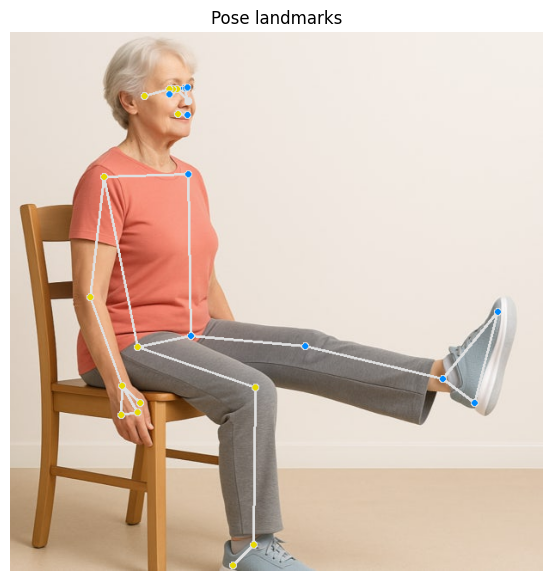

관절선 이미지 저장 위치: /content/silverfit_pose_project/outputs/annotated_images/single_pose_annotated.png


In [25]:
# ============================================================
# 5. 관절선 시각화 함수
# ============================================================

def draw_pose_on_image(rgb_image, results, save_path=None):
    """
    이미지 위에 MediaPipe 관절선 skeleton을 그립니다.
    """

    # 원본 이미지를 훼손하지 않기 위해 복사본을 만듭니다.
    annotated = rgb_image.copy()

    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image=annotated,
            landmark_list=results.pose_landmarks,
            connections=mp_pose.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style(),
        )

    if save_path is not None:
        # OpenCV 저장은 BGR을 기대하므로 RGB -> BGR 변환 후 저장합니다.
        cv2.imwrite(str(save_path), cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

    return annotated


annotated_path = ANNOTATED_DIR / "single_pose_annotated.png"
annotated_image = draw_pose_on_image(rgb_image, results, save_path=annotated_path)

plt.figure(figsize=(7, 7))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("Pose landmarks")
plt.show()

print("관절선 이미지 저장 위치:", annotated_path)

## 6. 각도 계산 함수

운동 자세 판단의 핵심은 관절 각도입니다.

예를 들어 무릎 각도는 아래 세 점으로 계산합니다.

```text
엉덩이 - 무릎 - 발목
```

이때 가운데 점인 `무릎`이 각도의 중심입니다.

In [26]:
# ============================================================
# 6. 각도 계산 함수
# ============================================================

def point_xy(landmarks, name):
    """
    특정 관절의 x, y 좌표를 numpy array로 반환합니다.
    z는 여기서는 사용하지 않습니다.
    """
    p = landmarks[name]
    return np.array([p["x"], p["y"]], dtype=np.float32)


def angle_abc(a, b, c):
    """
    세 점 A-B-C가 있을 때, B를 중심으로 하는 각도를 계산합니다.

    예: 엉덩이-무릎-발목 각도
    A = 엉덩이
    B = 무릎
    C = 발목
    결과 = 무릎 각도
    """

    # B에서 A로 향하는 벡터입니다.
    ba = a - b

    # B에서 C로 향하는 벡터입니다.
    bc = c - b

    # 벡터 길이가 0이면 각도를 계산할 수 없습니다.
    if np.linalg.norm(ba) == 0 or np.linalg.norm(bc) == 0:
        return np.nan

    # 코사인 법칙을 이용합니다.
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))

    # 계산 오차 때문에 cosine 값이 -1~1 범위를 살짝 벗어날 수 있어 잘라줍니다.
    cosine = np.clip(cosine, -1.0, 1.0)

    # arccos 결과는 라디안이므로 degree로 변환합니다.
    angle = np.degrees(np.arccos(cosine))

    return float(angle)


def line_angle_from_horizontal(p1, p2):
    """
    두 점을 잇는 선이 수평선과 이루는 각도를 계산합니다.

    결과 해석:
    - 0도에 가까움: 거의 수평
    - 90도에 가까움: 거의 수직
    """
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    angle = abs(np.degrees(np.arctan2(dy, dx)))

    # 180도 근처 각도는 0도 방향과 같은 수평에 가깝게 처리합니다.
    if angle > 90:
        angle = 180 - angle

    return float(angle)


def midpoint(p1, p2):
    """
    두 점의 중간점을 계산합니다.
    """
    return (p1 + p2) / 2.0

## 7. 자세 판단에 필요한 feature 계산

여기서는 주요 관절 각도를 계산합니다.

주요 feature:

- 왼쪽/오른쪽 무릎 각도
- 왼쪽/오른쪽 고관절 각도
- 왼쪽/오른쪽 팔꿈치 각도
- 몸통이 수평인지/수직인지
- 어깨-엉덩이-발목이 일직선인지
- 좌우 대칭이 깨졌는지

In [27]:
# ============================================================
# 7. 자세 feature 계산 함수
# ============================================================

def calculate_pose_features(landmarks):
    """
    MediaPipe 관절 좌표에서 운동 자세 판단에 필요한 숫자 feature를 계산합니다.
    """

    # 자주 쓰는 관절 좌표를 변수로 빼둡니다.
    LS = point_xy(landmarks, "LEFT_SHOULDER")
    RS = point_xy(landmarks, "RIGHT_SHOULDER")
    LE = point_xy(landmarks, "LEFT_ELBOW")
    RE = point_xy(landmarks, "RIGHT_ELBOW")
    LW = point_xy(landmarks, "LEFT_WRIST")
    RW = point_xy(landmarks, "RIGHT_WRIST")

    LH = point_xy(landmarks, "LEFT_HIP")
    RH = point_xy(landmarks, "RIGHT_HIP")
    LK = point_xy(landmarks, "LEFT_KNEE")
    RK = point_xy(landmarks, "RIGHT_KNEE")
    LA = point_xy(landmarks, "LEFT_ANKLE")
    RA = point_xy(landmarks, "RIGHT_ANKLE")

    # 좌우 중간점입니다.
    shoulder_mid = midpoint(LS, RS)
    hip_mid = midpoint(LH, RH)
    knee_mid = midpoint(LK, RK)
    ankle_mid = midpoint(LA, RA)

    # 관절 각도 계산입니다.
    features = {}

    # 무릎 각도: 엉덩이-무릎-발목
    features["left_knee_angle"] = angle_abc(LH, LK, LA)
    features["right_knee_angle"] = angle_abc(RH, RK, RA)

    # 고관절 각도: 어깨-엉덩이-무릎
    features["left_hip_angle"] = angle_abc(LS, LH, LK)
    features["right_hip_angle"] = angle_abc(RS, RH, RK)

    # 팔꿈치 각도: 어깨-팔꿈치-손목
    features["left_elbow_angle"] = angle_abc(LS, LE, LW)
    features["right_elbow_angle"] = angle_abc(RS, RE, RW)

    # 어깨 각도: 팔꿈치-어깨-엉덩이
    # 팔을 얼마나 들었는지 판단하는 데 사용합니다.
    features["left_shoulder_angle"] = angle_abc(LE, LS, LH)
    features["right_shoulder_angle"] = angle_abc(RE, RS, RH)

    # 몸통 라인 각도입니다.
    # 90도에 가까우면 서 있는 자세, 0도에 가까우면 누워 있는 자세에 가깝습니다.
    features["torso_angle_from_horizontal"] = line_angle_from_horizontal(shoulder_mid, hip_mid)

    # 어깨-엉덩이-발목이 얼마나 일직선인지 봅니다.
    # 플랭크/푸시업에서 매우 중요합니다.
    features["body_alignment_angle"] = angle_abc(shoulder_mid, hip_mid, ankle_mid)

    # 무릎 좌우 차이입니다.
    # 스쿼트에서 좌우 균형이 깨졌는지 볼 수 있습니다.
    features["knee_symmetry_diff"] = abs(features["left_knee_angle"] - features["right_knee_angle"])

    # 어깨 좌우 차이입니다.
    features["shoulder_symmetry_diff"] = abs(features["left_shoulder_angle"] - features["right_shoulder_angle"])

    # 주요 관절 visibility 평균입니다.
    # 낮으면 사진에서 관절이 가려졌다는 뜻입니다.
    key_names = [
        "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST", "RIGHT_WRIST",
        "LEFT_HIP", "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    ]
    features["mean_visibility"] = float(np.mean([landmarks[name]["visibility"] for name in key_names]))

    # 높이 관계도 저장합니다.
    # MediaPipe의 y는 위가 0, 아래가 1입니다.
    features["left_wrist_y"] = float(LW[1])
    features["right_wrist_y"] = float(RW[1])
    features["shoulder_mid_y"] = float(shoulder_mid[1])
    features["hip_mid_y"] = float(hip_mid[1])
    features["knee_mid_y"] = float(knee_mid[1])
    features["ankle_mid_y"] = float(ankle_mid[1])

    return features


if landmarks is not None:
    features = calculate_pose_features(landmarks)
    feature_df = pd.DataFrame([features]).T.reset_index()
    feature_df.columns = ["feature", "value"]
    display(feature_df)

,feature,value
0,left_knee_angle,172.021332
1,right_knee_angle,108.531776
2,left_hip_angle,96.064568
3,right_hip_angle,120.508232
4,left_elbow_angle,167.852951
5,right_elbow_angle,153.687286
6,left_shoulder_angle,2.773399
7,right_shoulder_angle,17.917778
8,torso_angle_from_horizontal,83.608482
9,body_alignment_angle,129.345505


## 8. 운동 자세 분류 규칙

이 단계는 머신러닝 학습 모델이 아니라 **각도 기반 규칙**입니다.

예시:

- 양쪽 무릎이 많이 접힘 → 스쿼트 가능성
- 한쪽 무릎만 많이 접힘 → 런지 가능성
- 몸통이 수평이고 어깨-엉덩이-발목이 일직선 → 플랭크/푸시업 가능성
- 손목이 어깨보다 위에 있음 → 팔 들기 가능성

장점:

- 데이터셋 없이 바로 프로토타입 가능
- 왜 그렇게 판단했는지 설명 가능

단점:

- 다양한 카메라 각도와 사람 체형에 약함
- 실제 서비스용으로는 데이터셋 기반 모델로 확장 필요

In [28]:
# ============================================================
# 8. 운동 자세 분류 함수
# ============================================================

def classify_exercise_pose(features):
    """
    계산된 관절 각도를 보고 운동 자세를 규칙 기반으로 분류합니다.
    """

    lk = features["left_knee_angle"]
    rk = features["right_knee_angle"]
    lh = features["left_hip_angle"]
    rh = features["right_hip_angle"]
    le = features["left_elbow_angle"]
    re = features["right_elbow_angle"]

    torso_h = features["torso_angle_from_horizontal"]
    body_align = features["body_alignment_angle"]

    knee_min = min(lk, rk)
    knee_max = max(lk, rk)
    knee_avg = (lk + rk) / 2
    hip_avg = (lh + rh) / 2
    elbow_avg = (le + re) / 2

    wrist_above_shoulder = (
        features["left_wrist_y"] < features["shoulder_mid_y"] and
        features["right_wrist_y"] < features["shoulder_mid_y"]
    )

    standing_like = torso_h > 55 and knee_avg > 140
    horizontal_like = torso_h < 35

    # 1) 플랭크 / 푸시업
    # 몸이 수평에 가깝고, 어깨-엉덩이-발목이 일직선에 가까우면 바닥 운동으로 봅니다.
    if horizontal_like and body_align > 145:
        if elbow_avg < 155:
            return {
                "pose_label": "push_up",
                "pose_name_kr": "푸시업",
                "confidence": 0.82,
                "reason": "몸통이 수평에 가깝고 팔꿈치가 굽어 있어 푸시업 자세로 판단했습니다.",
            }
        else:
            return {
                "pose_label": "plank",
                "pose_name_kr": "플랭크",
                "confidence": 0.84,
                "reason": "몸통이 수평에 가깝고 어깨-엉덩이-발목 라인이 일직선에 가까워 플랭크 자세로 판단했습니다.",
            }

    # 2) 스쿼트
    # 양쪽 무릎이 함께 굽혀져 있고, 고관절도 접혀 있으면 스쿼트로 봅니다.
    if 60 <= lk <= 145 and 60 <= rk <= 145 and hip_avg < 150 and torso_h > 35:
        return {
            "pose_label": "squat",
            "pose_name_kr": "스쿼트",
            "confidence": 0.86,
            "reason": "양쪽 무릎과 고관절이 함께 굽혀져 있어 스쿼트 자세로 판단했습니다.",
        }

    # 3) 런지
    # 한쪽 무릎은 굽고, 반대쪽 무릎은 상대적으로 펴져 있으면 런지로 봅니다.
    if knee_min < 130 and knee_max > 135 and abs(lk - rk) > 25 and torso_h > 40:
        return {
            "pose_label": "lunge",
            "pose_name_kr": "런지",
            "confidence": 0.78,
            "reason": "좌우 무릎 각도 차이가 크고 한쪽 무릎이 더 굽혀져 있어 런지 자세로 판단했습니다.",
        }

    # 4) 팔 들기 / 만세 동작
    if standing_like and wrist_above_shoulder:
        return {
            "pose_label": "arm_raise",
            "pose_name_kr": "팔 들기",
            "confidence": 0.76,
            "reason": "서 있는 상태에서 양손이 어깨보다 위에 있어 팔 들기 동작으로 판단했습니다.",
        }

    # 5) 무릎 들기
    # 한쪽 무릎이 반대쪽보다 확실히 높이 올라온 경우를 간단히 감지합니다.
    # y값은 작을수록 위에 있다는 뜻입니다.
    left_knee_y = landmarks["LEFT_KNEE"]["y"]
    right_knee_y = landmarks["RIGHT_KNEE"]["y"]
    hip_y = features["hip_mid_y"]

    if standing_like and (left_knee_y < hip_y or right_knee_y < hip_y):
        return {
            "pose_label": "knee_raise",
            "pose_name_kr": "무릎 들기",
            "confidence": 0.72,
            "reason": "서 있는 상태에서 한쪽 무릎이 높게 올라와 무릎 들기 동작으로 판단했습니다.",
        }

    # 6) 기본 서기/기타
    if standing_like:
        return {
            "pose_label": "standing_or_unknown",
            "pose_name_kr": "기본 서기 또는 기타 동작",
            "confidence": 0.55,
            "reason": "몸통이 수직에 가깝고 무릎이 펴져 있어 기본 서기 또는 명확하지 않은 동작으로 판단했습니다.",
        }

    # 어느 규칙에도 명확히 들어가지 않으면 unknown 처리합니다.
    return {
        "pose_label": "unknown",
        "pose_name_kr": "판단 어려움",
        "confidence": 0.40,
        "reason": "현재 규칙으로는 자세를 명확히 분류하기 어렵습니다. 전신이 더 잘 보이는 사진을 사용하세요.",
    }


if landmarks is not None:
    pose_result = classify_exercise_pose(features)
    print(json.dumps(pose_result, ensure_ascii=False, indent=2))

{
  "pose_label": "lunge",
  "pose_name_kr": "런지",
  "confidence": 0.78,
  "reason": "좌우 무릎 각도 차이가 크고 한쪽 무릎이 더 굽혀져 있어 런지 자세로 판단했습니다."
}


## 9. 시니어 안전 관점 피드백

이 부분은 프로젝트 차별화 포인트입니다.

단순히 “스쿼트입니다”라고 끝내지 않고,

- 무릎이 너무 많이 접혔는지
- 좌우 균형이 깨졌는지
- 플랭크에서 허리가 처졌는지
- 사진에서 관절이 잘 보이는지

같은 요소를 점검합니다.

In [29]:
# ============================================================
# 9. 안전 점수와 피드백 함수
# ============================================================

def make_safety_feedback(pose_result, features):
    """
    자세 종류와 관절 feature를 기반으로 시니어 안전 피드백을 만듭니다.

    Returns
    -------
    safety : dict
        safety_score, risk_level, feedback 리스트를 포함합니다.
    """

    score = 100
    feedback = []

    label = pose_result["pose_label"]

    # 1) 관절 visibility가 낮으면 분석 신뢰도가 떨어집니다.
    if features["mean_visibility"] < 0.55:
        score -= 25
        feedback.append("팔이나 다리 일부가 가려져 관절 인식 신뢰도가 낮습니다. 전신이 더 잘 보이게 다시 촬영하세요.")
    elif features["mean_visibility"] < 0.75:
        score -= 10
        feedback.append("일부 관절이 선명하지 않습니다. 밝은 곳에서 전신이 보이도록 촬영하면 분석이 더 좋아집니다.")

    # 2) 스쿼트 안전 체크
    if label == "squat":
        lk = features["left_knee_angle"]
        rk = features["right_knee_angle"]
        knee_avg = (lk + rk) / 2

        # 시니어 홈트에서는 너무 깊은 스쿼트를 위험으로 볼 수 있습니다.
        if knee_avg < 70:
            score -= 20
            feedback.append("무릎이 많이 접혀 깊은 스쿼트로 보입니다. 시니어 운동에서는 의자 스쿼트처럼 깊이를 줄이는 편이 안전합니다.")
        elif knee_avg > 145:
            score -= 8
            feedback.append("무릎 굽힘이 작아 스쿼트 동작이 충분하지 않을 수 있습니다. 단, 통증이 있다면 얕은 범위가 안전합니다.")
        else:
            feedback.append("무릎 굽힘 범위는 대체로 무난합니다.")

        # 좌우 무릎 각도 차이가 크면 균형 문제가 있을 수 있습니다.
        if features["knee_symmetry_diff"] > 25:
            score -= 18
            feedback.append("좌우 무릎 각도 차이가 큽니다. 한쪽으로 체중이 쏠리지 않도록 의자나 벽을 잡고 천천히 수행하세요.")

        # 몸통이 너무 앞으로 숙여진 경우입니다.
        # torso_angle_from_horizontal이 낮을수록 몸통이 수평에 가까운 것입니다.
        if features["torso_angle_from_horizontal"] < 45:
            score -= 12
            feedback.append("상체가 앞으로 많이 숙여진 것으로 보입니다. 허리를 세우고 시선은 정면을 유지하세요.")

    # 3) 런지 안전 체크
    elif label == "lunge":
        lk = features["left_knee_angle"]
        rk = features["right_knee_angle"]
        front_knee_angle = min(lk, rk)

        if front_knee_angle < 65:
            score -= 22
            feedback.append("앞쪽 무릎이 너무 깊게 접힌 런지로 보입니다. 시니어에게는 무릎 부담이 커질 수 있어 보폭과 깊이를 줄이세요.")
        elif front_knee_angle > 130:
            score -= 8
            feedback.append("런지 동작의 무릎 굽힘이 작아 운동 자극이 약할 수 있습니다. 안전 범위에서만 조금 더 굽혀보세요.")
        else:
            feedback.append("런지의 무릎 굽힘 범위는 대체로 무난합니다.")

        if features["torso_angle_from_horizontal"] < 50:
            score -= 10
            feedback.append("런지 중 상체가 많이 기울어진 것으로 보입니다. 몸통을 세우고 천천히 내려가세요.")

    # 4) 플랭크 안전 체크
    elif label == "plank":
        if features["body_alignment_angle"] < 160:
            score -= 22
            feedback.append("어깨-엉덩이-발목 라인이 일직선에서 벗어났습니다. 허리가 처지거나 엉덩이가 들리지 않게 조정하세요.")
        else:
            feedback.append("몸통 정렬은 대체로 좋습니다.")

        if features["mean_visibility"] >= 0.75:
            feedback.append("시니어에게는 긴 플랭크보다 10~20초 짧은 세트로 나누는 방식이 안전합니다.")

    # 5) 푸시업 안전 체크
    elif label == "push_up":
        elbow_avg = (features["left_elbow_angle"] + features["right_elbow_angle"]) / 2

        if features["body_alignment_angle"] < 155:
            score -= 20
            feedback.append("푸시업 중 몸통 정렬이 무너진 것으로 보입니다. 무릎 대고 푸시업으로 난이도를 낮추는 것을 권장합니다.")

        if elbow_avg < 55:
            score -= 15
            feedback.append("팔꿈치가 많이 접혀 어깨와 팔꿈치 부담이 커질 수 있습니다. 가동 범위를 줄이세요.")
        else:
            feedback.append("팔꿈치 굽힘은 과도하지 않은 편입니다.")

    # 6) 팔 들기 안전 체크
    elif label == "arm_raise":
        if features["shoulder_symmetry_diff"] > 30:
            score -= 15
            feedback.append("좌우 팔 높이 차이가 큽니다. 어깨 통증이 있다면 양팔을 같은 높이까지만 천천히 들어올리세요.")
        else:
            feedback.append("좌우 팔 높이는 비교적 균형이 맞습니다.")

        feedback.append("어깨가 아프면 머리 위까지 올리지 말고 어깨 높이까지만 수행하세요.")

    # 7) 무릎 들기 안전 체크
    elif label == "knee_raise":
        feedback.append("무릎 들기 동작은 균형이 중요합니다. 시니어의 경우 벽이나 의자를 잡고 수행하는 것이 안전합니다.")

    # 8) 알 수 없는 동작
    else:
        score -= 20
        feedback.append("동작이 명확하지 않습니다. 정면 또는 측면에서 전신이 잘 보이는 사진으로 다시 촬영하세요.")

    # 점수 범위를 0~100으로 제한합니다.
    score = max(0, min(100, int(round(score))))

    # 위험도 등급을 정합니다.
    if score >= 80:
        risk_level = "안전"
    elif score >= 60:
        risk_level = "주의"
    else:
        risk_level = "위험"

    return {
        "safety_score": score,
        "risk_level": risk_level,
        "feedback": feedback,
    }


if landmarks is not None:
    safety_result = make_safety_feedback(pose_result, features)
    print(json.dumps(safety_result, ensure_ascii=False, indent=2))

{
  "safety_score": 100,
  "risk_level": "안전",
  "feedback": [
    "런지의 무릎 굽힘 범위는 대체로 무난합니다."
  ]
}


## 10. 최종 분석 리포트 생성

아래 셀은 위 결과를 한 번에 보기 좋은 표 형태로 정리합니다.

In [30]:
# ============================================================
# 10. 최종 분석 리포트 생성
# ============================================================

if landmarks is not None:
    final_report = {
        "image_file": image_path,
        "predicted_pose": pose_result["pose_name_kr"],
        "pose_label": pose_result["pose_label"],
        "pose_confidence_rule_based": pose_result["confidence"],
        "safety_score": safety_result["safety_score"],
        "risk_level": safety_result["risk_level"],
        "reason": pose_result["reason"],
        "feedback": " / ".join(safety_result["feedback"]),
        "annotated_image_path": str(annotated_path),
    }

    report_df = pd.DataFrame([final_report])
    display(report_df)

    # CSV와 JSON으로 저장합니다.
    report_csv_path = OUTPUT_DIR / "single_pose_report.csv"
    report_json_path = OUTPUT_DIR / "single_pose_report.json"

    report_df.to_csv(report_csv_path, index=False, encoding="utf-8-sig")
    with open(report_json_path, "w", encoding="utf-8") as f:
        json.dump(final_report, f, ensure_ascii=False, indent=2)

    print("CSV 저장:", report_csv_path)
    print("JSON 저장:", report_json_path)

,image_file,predicted_pose,pose_label,pose_confidence_rule_based,safety_score,risk_level,reason,feedback,annotated_image_path
0,다운로드 (1).jpg,런지,lunge,0.78,100,안전,좌우 무릎 각도 차이가 크고 한쪽 무릎이 더 굽혀져 있어 런지 자세로 판단했습니다.,런지의 무릎 굽힘 범위는 대체로 무난합니다.,/content/silverfit_pose_project/outputs/annota...


CSV 저장: /content/silverfit_pose_project/outputs/single_pose_report.csv
JSON 저장: /content/silverfit_pose_project/outputs/single_pose_report.json


## 11. 전체 분석을 함수 하나로 묶기

위에서 하나씩 실행한 과정을 `analyze_pose_image()` 함수 하나로 묶습니다.  
여러 장을 분석하거나, 나중에 웹앱/키오스크에 붙일 때 이 함수만 가져가면 됩니다.

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47088 (\N{HANGUL SYLLABLE REON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph

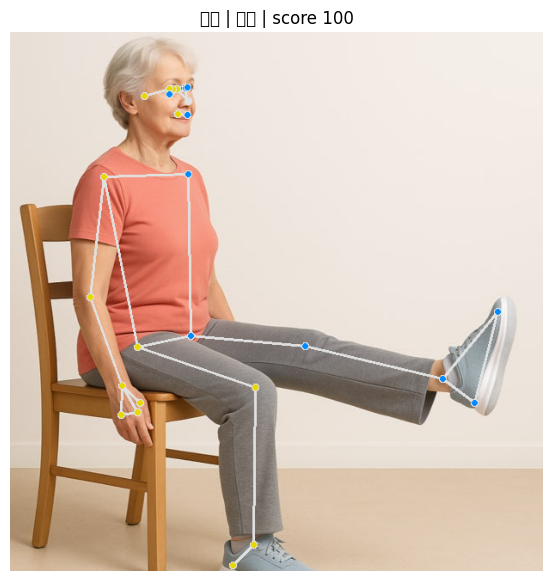

,image_file,predicted_pose,pose_label,pose_confidence_rule_based,safety_score,risk_level,reason,feedback,annotated_image_path
0,다운로드 (1).jpg,런지,lunge,0.78,100,안전,좌우 무릎 각도 차이가 크고 한쪽 무릎이 더 굽혀져 있어 런지 자세로 판단했습니다.,런지의 무릎 굽힘 범위는 대체로 무난합니다.,/content/silverfit_pose_project/outputs/annota...


In [31]:
# ============================================================
# 11. 전체 분석 함수
# ============================================================

def analyze_pose_image(image_path, detector=pose_detector, show=True):
    """
    이미지 1장을 입력받아 자세 분석 전체 과정을 수행합니다.

    Parameters
    ----------
    image_path : str or Path
        분석할 이미지 파일 경로입니다.
    detector : mediapipe Pose object
        MediaPipe Pose 객체입니다.
    show : bool
        True이면 결과 이미지를 화면에 보여줍니다.

    Returns
    -------
    result_dict : dict
        자세 라벨, 안전 점수, 피드백, 저장 경로 등이 들어 있습니다.
    feature_dict : dict
        계산된 관절 각도 feature입니다.
    """

    image_path = Path(image_path)

    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise ValueError(f"이미지를 읽지 못했습니다: {image_path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # 1) 관절 추출
    results, landmarks = extract_pose_landmarks(rgb, detector)

    if landmarks is None:
        result_dict = {
            "image_file": image_path.name,
            "predicted_pose": "사람 자세 감지 실패",
            "pose_label": "no_pose_detected",
            "pose_confidence_rule_based": 0.0,
            "safety_score": 0,
            "risk_level": "판단 불가",
            "reason": "MediaPipe가 사람의 전신 포즈를 감지하지 못했습니다.",
            "feedback": "전신이 보이는 밝은 사진으로 다시 촬영하세요.",
            "annotated_image_path": "",
        }
        return result_dict, {}

    # 2) feature 계산
    feature_dict = calculate_pose_features(landmarks)

    # 3) 자세 분류
    pose_result = classify_exercise_pose(feature_dict)

    # 4) 안전 피드백
    safety_result = make_safety_feedback(pose_result, feature_dict)

    # 5) 관절선 이미지 저장
    annotated_name = image_path.stem + "_annotated.png"
    annotated_path = ANNOTATED_DIR / annotated_name
    annotated = draw_pose_on_image(rgb, results, save_path=annotated_path)

    # 6) 결과 딕셔너리 구성
    result_dict = {
        "image_file": image_path.name,
        "predicted_pose": pose_result["pose_name_kr"],
        "pose_label": pose_result["pose_label"],
        "pose_confidence_rule_based": pose_result["confidence"],
        "safety_score": safety_result["safety_score"],
        "risk_level": safety_result["risk_level"],
        "reason": pose_result["reason"],
        "feedback": " / ".join(safety_result["feedback"]),
        "annotated_image_path": str(annotated_path),
    }

    if show:
        plt.figure(figsize=(7, 7))
        plt.imshow(annotated)
        plt.axis("off")
        plt.title(f"{result_dict['predicted_pose']} | {result_dict['risk_level']} | score {result_dict['safety_score']}")
        plt.show()

        display(pd.DataFrame([result_dict]))

    return result_dict, feature_dict


# 방금 업로드한 이미지로 함수 테스트
single_result, single_features = analyze_pose_image(image_path, show=True)

In [32]:
# ============================================================
# 11-1. batch 분석용 feature 보정 셀
# ============================================================
# 위치:
# - 반드시 11번 analyze_pose_image() 함수 셀 실행 후
# - 12번 여러 장 batch 분석 셀 실행 전에 넣습니다.
#
# 목적:
# - 여러 장 이미지를 분석할 때 전역 landmarks 변수 때문에
#   다른 이미지의 관절값이 섞이는 문제를 방지합니다.
# ============================================================

_original_calculate_pose_features = calculate_pose_features

def calculate_pose_features(landmarks):
    """
    기존 calculate_pose_features() 함수 결과에
    batch 분석에 필요한 관절 y좌표를 추가하는 보정 함수입니다.

    y값은 이미지 좌표 기준입니다.
    - y값이 작을수록 화면 위쪽
    - y값이 클수록 화면 아래쪽
    """

    # 기존 feature 계산 함수를 먼저 실행합니다.
    features = _original_calculate_pose_features(landmarks)

    # 무릎, 발목 위치를 추가로 저장합니다.
    # 여러 장 분석에서는 현재 이미지의 landmarks만 써야 하므로
    # features 안에 필요한 값을 넣어둡니다.
    features["left_knee_y"] = float(landmarks["LEFT_KNEE"]["y"])
    features["right_knee_y"] = float(landmarks["RIGHT_KNEE"]["y"])
    features["left_ankle_y"] = float(landmarks["LEFT_ANKLE"]["y"])
    features["right_ankle_y"] = float(landmarks["RIGHT_ANKLE"]["y"])

    return features

print("batch 분석용 feature 보정 완료")

batch 분석용 feature 보정 완료


## 12. 여러 장 한 번에 분석하기

여러 운동 자세 사진을 업로드하면 한 번에 분석하고 CSV로 저장합니다.

여러 장의 운동 자세 이미지를 업로드하세요.


Saving pexels-shvetsa-5067712.jpg to pexels-shvetsa-5067712.jpg
Saving pexels-shvetsa-5067742.jpg to pexels-shvetsa-5067742.jpg
Saving pexels-shvetsa-5067743.jpg to pexels-shvetsa-5067743.jpg
Saving pexels-shvets-production-8899507.jpg to pexels-shvets-production-8899507.jpg
Saving pexels-mikhail-nilov-7530009.jpg to pexels-mikhail-nilov-7530009.jpg
Saving pexels-shvets-production-8899512.jpg to pexels-shvets-production-8899512.jpg
Saving pexels-yankrukov-6815738.jpg to pexels-yankrukov-6815738.jpg
Saving pexels-yankrukov-6815698.jpg to pexels-yankrukov-6815698.jpg
Saving pexels-a-darmel-7322460 (1).jpg to pexels-a-darmel-7322460 (1).jpg
업로드 이미지 수: 9장
저장 위치: /content/silverfit_batch_inputs
분석 중: img_001.jpg
원본 파일명: pexels-shvetsa-5067712.jpg


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


분석 성공
예측 자세: 런지
안전 점수: 78
위험도: 주의
분석 중: img_002.jpg
원본 파일명: pexels-shvetsa-5067742.jpg
분석 성공
예측 자세: 무릎 들기
안전 점수: 100
위험도: 안전
분석 중: img_003.jpg
원본 파일명: pexels-shvetsa-5067743.jpg
분석 성공
예측 자세: 스쿼트
안전 점수: 82
위험도: 안전
분석 중: img_004.jpg
원본 파일명: pexels-shvets-production-8899507.jpg
분석 성공
예측 자세: 팔 들기
안전 점수: 100
위험도: 안전
분석 중: img_005.jpg
원본 파일명: pexels-mikhail-nilov-7530009.jpg
분석 성공
예측 자세: 판단 어려움
안전 점수: 80
위험도: 안전
분석 중: img_006.jpg
원본 파일명: pexels-shvets-production-8899512.jpg
분석 성공
예측 자세: 런지
안전 점수: 100
위험도: 안전
분석 중: img_007.jpg
원본 파일명: pexels-yankrukov-6815738.jpg
분석 성공
예측 자세: 기본 서기 또는 기타 동작
안전 점수: 80
위험도: 안전
분석 중: img_008.jpg
원본 파일명: pexels-yankrukov-6815698.jpg
분석 성공
예측 자세: 무릎 들기
안전 점수: 100
위험도: 안전
분석 중: img_009.jpg
원본 파일명: pexels-a-darmel-7322460 (1).jpg
분석 성공
예측 자세: 판단 어려움
안전 점수: 70
위험도: 주의


========== Batch 분석 결과표 ==========


,original_file,safe_file,predicted_pose,pose_label,pose_confidence_rule_based,safety_score,risk_level,reason,feedback,annotated_image_path
0,pexels-shvetsa-5067712.jpg,img_001.jpg,런지,lunge,0.78,78,주의,좌우 무릎 각도 차이가 크고 한쪽 무릎이 더 굽혀져 있어 런지 자세로 판단했습니다.,앞쪽 무릎이 너무 깊게 접힌 런지로 보입니다. 시니어에게는 무릎 부담이 커질 수 있...,/content/silverfit_pose_project/outputs/annota...
1,pexels-shvetsa-5067742.jpg,img_002.jpg,무릎 들기,knee_raise,0.72,100,안전,서 있는 상태에서 한쪽 무릎이 높게 올라와 무릎 들기 동작으로 판단했습니다.,무릎 들기 동작은 균형이 중요합니다. 시니어의 경우 벽이나 의자를 잡고 수행하는 것...,/content/silverfit_pose_project/outputs/annota...
2,pexels-shvetsa-5067743.jpg,img_003.jpg,스쿼트,squat,0.86,82,안전,양쪽 무릎과 고관절이 함께 굽혀져 있어 스쿼트 자세로 판단했습니다.,무릎 굽힘 범위는 대체로 무난합니다. / 좌우 무릎 각도 차이가 큽니다. 한쪽으로 ...,/content/silverfit_pose_project/outputs/annota...
3,pexels-shvets-production-8899507.jpg,img_004.jpg,팔 들기,arm_raise,0.76,100,안전,서 있는 상태에서 양손이 어깨보다 위에 있어 팔 들기 동작으로 판단했습니다.,좌우 팔 높이는 비교적 균형이 맞습니다. / 어깨가 아프면 머리 위까지 올리지 말고...,/content/silverfit_pose_project/outputs/annota...
4,pexels-mikhail-nilov-7530009.jpg,img_005.jpg,판단 어려움,unknown,0.40,80,안전,현재 규칙으로는 자세를 명확히 분류하기 어렵습니다. 전신이 더 잘 보이는 사진을 사...,동작이 명확하지 않습니다. 정면 또는 측면에서 전신이 잘 보이는 사진으로 다시 촬영...,/content/silverfit_pose_project/outputs/annota...
5,pexels-shvets-production-8899512.jpg,img_006.jpg,런지,lunge,0.78,100,안전,좌우 무릎 각도 차이가 크고 한쪽 무릎이 더 굽혀져 있어 런지 자세로 판단했습니다.,런지의 무릎 굽힘 범위는 대체로 무난합니다.,/content/silverfit_pose_project/outputs/annota...
6,pexels-yankrukov-6815738.jpg,img_007.jpg,기본 서기 또는 기타 동작,standing_or_unknown,0.55,80,안전,몸통이 수직에 가깝고 무릎이 펴져 있어 기본 서기 또는 명확하지 않은 동작으로 판단...,동작이 명확하지 않습니다. 정면 또는 측면에서 전신이 잘 보이는 사진으로 다시 촬영...,/content/silverfit_pose_project/outputs/annota...
7,pexels-yankrukov-6815698.jpg,img_008.jpg,무릎 들기,knee_raise,0.72,100,안전,서 있는 상태에서 한쪽 무릎이 높게 올라와 무릎 들기 동작으로 판단했습니다.,무릎 들기 동작은 균형이 중요합니다. 시니어의 경우 벽이나 의자를 잡고 수행하는 것...,/content/silverfit_pose_project/outputs/annota...
8,pexels-a-darmel-7322460 (1).jpg,img_009.jpg,판단 어려움,unknown,0.40,70,주의,현재 규칙으로는 자세를 명확히 분류하기 어렵습니다. 전신이 더 잘 보이는 사진을 사...,일부 관절이 선명하지 않습니다. 밝은 곳에서 전신이 보이도록 촬영하면 분석이 더 좋...,/content/silverfit_pose_project/outputs/annota...




========== 관절 각도 Feature 표 ==========


,safe_file,original_file,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,...,left_wrist_y,right_wrist_y,shoulder_mid_y,hip_mid_y,knee_mid_y,ankle_mid_y,left_knee_y,right_knee_y,left_ankle_y,right_ankle_y
0,img_001.jpg,pexels-shvetsa-5067712.jpg,168.543045,17.540636,104.300301,69.295540,161.062088,124.360390,48.301426,0.687565,...,0.637707,0.625238,0.427029,0.610184,0.644857,0.720097,0.684281,0.605434,0.740925,0.699269
1,img_002.jpg,pexels-shvetsa-5067742.jpg,178.070145,178.288330,167.773804,163.698410,170.286728,179.347473,29.556293,31.259567,...,0.600680,0.591348,0.411750,0.600890,0.742395,0.868253,0.743526,0.741265,0.868596,0.867910
2,img_003.jpg,pexels-shvetsa-5067743.jpg,74.804367,133.993759,107.022057,127.773651,157.148819,163.593903,11.809008,19.487389,...,0.586992,0.620124,0.370212,0.591685,0.698418,0.781119,0.654430,0.742407,0.809197,0.753040
3,img_004.jpg,pexels-shvets-production-8899507.jpg,177.742844,179.192551,176.675613,174.108368,174.447617,175.323120,104.159302,99.376503,...,0.216483,0.217020,0.250145,0.606139,0.875952,1.120893,0.878348,0.873556,1.112747,1.129040
4,img_005.jpg,pexels-mikhail-nilov-7530009.jpg,27.301693,16.318615,111.721565,65.417168,135.060150,116.461861,137.120895,11.770984,...,0.456502,0.725061,0.566846,0.739100,0.729621,0.788832,0.753913,0.705328,0.787913,0.789752
5,img_006.jpg,pexels-shvets-production-8899512.jpg,101.759560,170.849472,120.347214,162.240768,171.055527,159.551132,81.203278,63.925827,...,0.381877,0.353113,0.326233,0.491077,0.569940,0.683509,0.575425,0.564456,0.681522,0.685495
6,img_007.jpg,pexels-yankrukov-6815738.jpg,177.816895,175.920853,167.320847,153.240997,133.827988,120.712112,173.774261,29.575476,...,0.154486,0.515550,0.334720,0.521734,0.650381,0.768703,0.645871,0.654891,0.770558,0.766848
7,img_008.jpg,pexels-yankrukov-6815698.jpg,161.816360,178.073486,146.021652,147.038849,172.848419,172.171906,76.074394,72.024628,...,0.487666,0.432644,0.416375,0.648431,0.764878,0.868155,0.787063,0.742693,0.935740,0.800569
8,img_009.jpg,pexels-a-darmel-7322460 (1).jpg,171.588165,158.491150,114.625488,152.976883,149.407501,162.047791,28.341360,99.616676,...,0.775000,0.719953,0.432102,0.587238,0.608742,0.628690,0.595165,0.622320,0.618423,0.638958




========== 관절선 결과 이미지 출력 ==========
--------------------------------------------------------------------------------
원본 파일: pexels-shvetsa-5067712.jpg
예측 자세: 런지
안전 점수: 78
위험도: 주의
피드백: 앞쪽 무릎이 너무 깊게 접힌 런지로 보입니다. 시니어에게는 무릎 부담이 커질 수 있어 보폭과 깊이를 줄이세요.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47088 (\N{HANGUL SYLLABLE REON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


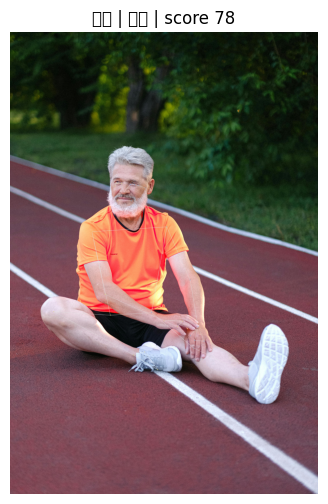

--------------------------------------------------------------------------------
원본 파일: pexels-shvetsa-5067742.jpg
예측 자세: 무릎 들기
안전 점수: 100
위험도: 안전
피드백: 무릎 들기 동작은 균형이 중요합니다. 시니어의 경우 벽이나 의자를 잡고 수행하는 것이 안전합니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47502 (\N{HANGUL SYLLABLE REUP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

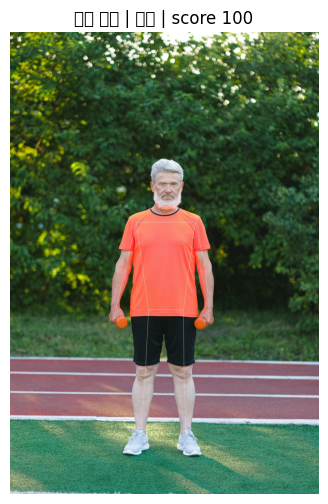

--------------------------------------------------------------------------------
원본 파일: pexels-shvetsa-5067743.jpg
예측 자세: 스쿼트
안전 점수: 82
위험도: 안전
피드백: 무릎 굽힘 범위는 대체로 무난합니다. / 좌우 무릎 각도 차이가 큽니다. 한쪽으로 체중이 쏠리지 않도록 의자나 벽을 잡고 천천히 수행하세요.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53244 (\N{HANGUL SYLLABLE KWEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


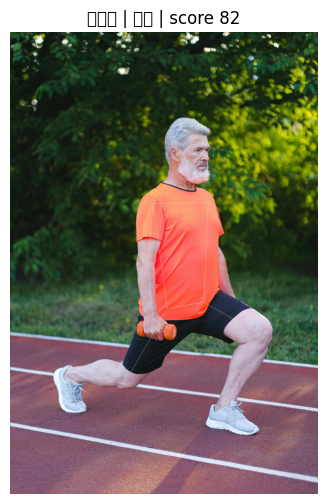

--------------------------------------------------------------------------------
원본 파일: pexels-shvets-production-8899507.jpg
예측 자세: 팔 들기
안전 점수: 100
위험도: 안전
피드백: 좌우 팔 높이는 비교적 균형이 맞습니다. / 어깨가 아프면 머리 위까지 올리지 말고 어깨 높이까지만 수행하세요.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54036 (\N{HANGUL SYLLABLE PAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


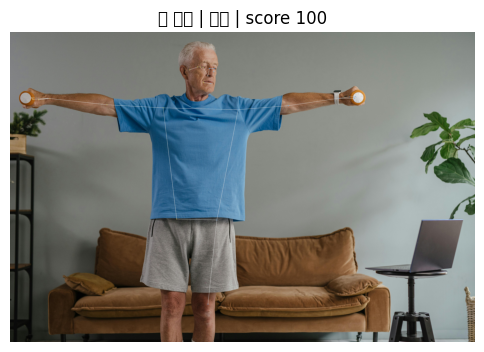

--------------------------------------------------------------------------------
원본 파일: pexels-mikhail-nilov-7530009.jpg
예측 자세: 판단 어려움
안전 점수: 80
위험도: 안전
피드백: 동작이 명확하지 않습니다. 정면 또는 측면에서 전신이 잘 보이는 사진으로 다시 촬영하세요.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47140 (\N{HANGUL SYLLABLE RYEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50880 (\N{HANGUL SYLLABLE UM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


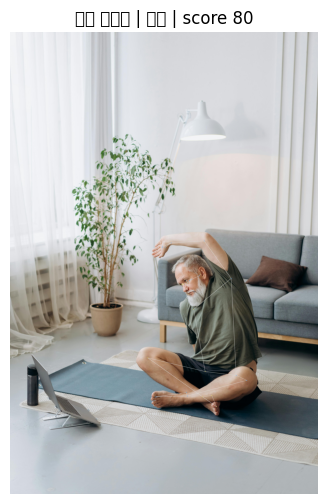

--------------------------------------------------------------------------------
원본 파일: pexels-shvets-production-8899512.jpg
예측 자세: 런지
안전 점수: 100
위험도: 안전
피드백: 런지의 무릎 굽힘 범위는 대체로 무난합니다.


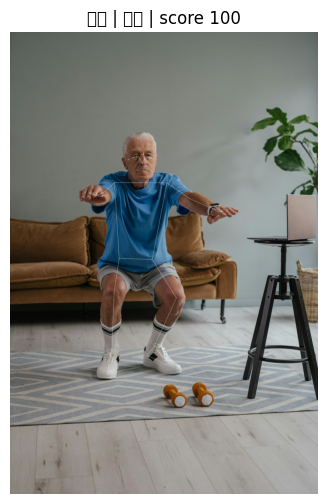

--------------------------------------------------------------------------------
원본 파일: pexels-yankrukov-6815738.jpg
예측 자세: 기본 서기 또는 기타 동작
안전 점수: 80
위험도: 안전
피드백: 동작이 명확하지 않습니다. 정면 또는 측면에서 전신이 잘 보이는 사진으로 다시 촬영하세요.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46608 (\N{HANGUL SYLLABLE DDO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

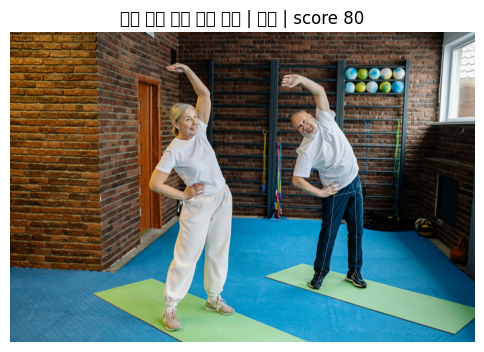

--------------------------------------------------------------------------------
원본 파일: pexels-yankrukov-6815698.jpg
예측 자세: 무릎 들기
안전 점수: 100
위험도: 안전
피드백: 무릎 들기 동작은 균형이 중요합니다. 시니어의 경우 벽이나 의자를 잡고 수행하는 것이 안전합니다.


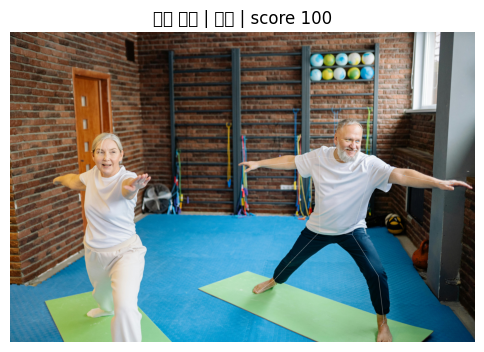

--------------------------------------------------------------------------------
원본 파일: pexels-a-darmel-7322460 (1).jpg
예측 자세: 판단 어려움
안전 점수: 70
위험도: 주의
피드백: 일부 관절이 선명하지 않습니다. 밝은 곳에서 전신이 보이도록 촬영하면 분석이 더 좋아집니다. / 동작이 명확하지 않습니다. 정면 또는 측면에서 전신이 잘 보이는 사진으로 다시 촬영하세요.


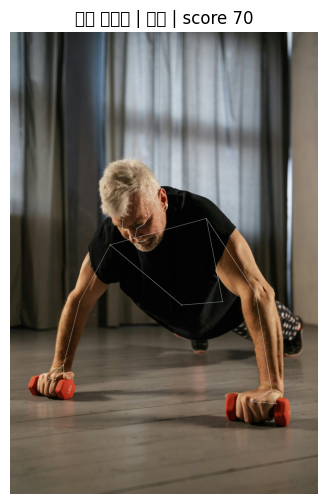



========== 저장 완료 ==========
분석 결과 CSV: /content/silverfit_pose_project/outputs/batch_pose_report.csv
관절 feature CSV: /content/silverfit_pose_project/outputs/batch_pose_features.csv
분석 결과 JSON: /content/silverfit_pose_project/outputs/batch_pose_report.json


In [34]:
# ============================================================
# 12. 여러 장 이미지 batch 분석 + 함수 테스트 출력
# ============================================================
# 목적:
# 1) 여러 장 이미지를 한 번에 업로드합니다.
# 2) 각 이미지마다 analyze_pose_image() 함수를 실행합니다.
# 3) 분석 결과표를 출력합니다.
# 4) 관절선이 그려진 결과 이미지를 하나씩 화면에 보여줍니다.
# 5) CSV / JSON 파일로 저장합니다.
#
# 실행 위치:
# - 반드시 analyze_pose_image() 함수가 정의된 뒤에 실행해야 합니다.
# - 즉, 노트북의 11번 셀까지 실행한 다음 이 셀을 실행하세요.
# ============================================================

from google.colab import files
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import json
import shutil
import traceback

# ------------------------------------------------------------
# 1. batch 입력 폴더 만들기
# ------------------------------------------------------------
# 업로드된 파일명이 한글이거나 공백이 있으면 OpenCV에서 읽기 실패할 수 있습니다.
# 그래서 업로드 후 img_001.jpg 같은 안전한 영어 파일명으로 다시 저장합니다.
# ------------------------------------------------------------

BATCH_INPUT_DIR = Path("/content/silverfit_batch_inputs")
BATCH_INPUT_DIR.mkdir(parents=True, exist_ok=True)

# 이전 테스트 파일이 섞이지 않도록 폴더를 비웁니다.
for old_file in BATCH_INPUT_DIR.glob("*"):
    old_file.unlink()

print("여러 장의 운동 자세 이미지를 업로드하세요.")
batch_uploaded = files.upload()

# ------------------------------------------------------------
# 2. 업로드 파일을 안전한 파일명으로 저장
# ------------------------------------------------------------

image_paths = []
original_name_map = {}

allowed_exts = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

for idx, (original_name, file_bytes) in enumerate(batch_uploaded.items(), start=1):
    ext = Path(original_name).suffix.lower()

    # 확장자가 없거나 이미지 확장자가 아니면 기본 jpg로 처리합니다.
    if ext not in allowed_exts:
        ext = ".jpg"

    safe_name = f"img_{idx:03d}{ext}"
    safe_path = BATCH_INPUT_DIR / safe_name

    # 업로드된 파일 내용을 새 경로에 저장합니다.
    with open(safe_path, "wb") as f:
        f.write(file_bytes)

    image_paths.append(safe_path)
    original_name_map[safe_name] = original_name

print(f"업로드 이미지 수: {len(image_paths)}장")
print("저장 위치:", BATCH_INPUT_DIR)

# ------------------------------------------------------------
# 3. 여러 장 분석 실행
# ------------------------------------------------------------
# analyze_pose_image()는 이전 셀에서 만든 전체 분석 함수입니다.
# 각 이미지마다:
# - 자세 추정
# - 관절 각도 계산
# - 위험도 계산
# - 관절선 이미지 저장
# 을 수행합니다.
# ------------------------------------------------------------

batch_results = []
batch_features = []

for image_path in image_paths:
    print("=" * 80)
    print("분석 중:", image_path.name)
    print("원본 파일명:", original_name_map.get(image_path.name, image_path.name))

    try:
        # show=False:
        # 여기서는 한 장씩 바로 보여주지 않고,
        # 아래에서 결과표를 만든 뒤 따로 보기 좋게 출력합니다.
        result, features = analyze_pose_image(image_path, show=False)

        # 안전한 파일명과 원본 파일명을 모두 저장합니다.
        result["safe_file"] = image_path.name
        result["original_file"] = original_name_map.get(image_path.name, image_path.name)

        batch_results.append(result)

        # 관절 각도 feature도 따로 저장합니다.
        if features:
            feature_row = {
                "safe_file": image_path.name,
                "original_file": original_name_map.get(image_path.name, image_path.name),
            }
            feature_row.update(features)
            batch_features.append(feature_row)

        print("분석 성공")
        print("예측 자세:", result.get("predicted_pose"))
        print("안전 점수:", result.get("safety_score"))
        print("위험도:", result.get("risk_level"))

    except Exception as e:
        # 특정 이미지 1장에서 에러가 나도 전체 분석이 멈추지 않도록 처리합니다.
        error_result = {
            "safe_file": image_path.name,
            "original_file": original_name_map.get(image_path.name, image_path.name),
            "image_file": image_path.name,
            "predicted_pose": "분석 실패",
            "pose_label": "error",
            "pose_confidence_rule_based": 0.0,
            "safety_score": 0,
            "risk_level": "분석 실패",
            "reason": str(e),
            "feedback": "이미지 파일 형식, 전신 노출 여부, 밝기, 해상도를 확인하세요.",
            "annotated_image_path": "",
        }
        batch_results.append(error_result)

        print("분석 실패:", image_path.name)
        print("에러 내용:", str(e))
        traceback.print_exc()

# ------------------------------------------------------------
# 4. 결과표 만들기
# ------------------------------------------------------------

batch_report_df = pd.DataFrame(batch_results)
batch_feature_df = pd.DataFrame(batch_features)

# 보기 좋은 컬럼 순서로 정리합니다.
main_columns = [
    "original_file",
    "safe_file",
    "predicted_pose",
    "pose_label",
    "pose_confidence_rule_based",
    "safety_score",
    "risk_level",
    "reason",
    "feedback",
    "annotated_image_path",
]

# 존재하는 컬럼만 사용합니다.
main_columns = [col for col in main_columns if col in batch_report_df.columns]
batch_report_df = batch_report_df[main_columns]

print("\n\n========== Batch 분석 결과표 ==========")
display(batch_report_df)

print("\n\n========== 관절 각도 Feature 표 ==========")
if len(batch_feature_df) > 0:
    display(batch_feature_df)
else:
    print("저장된 feature가 없습니다. 사람 자세 감지에 실패했을 가능성이 있습니다.")

# ------------------------------------------------------------
# 5. 결과 이미지 출력
# ------------------------------------------------------------
# 각 이미지에 MediaPipe 관절선이 그려진 결과를 화면에 보여줍니다.
# ------------------------------------------------------------

print("\n\n========== 관절선 결과 이미지 출력 ==========")

for _, row in batch_report_df.iterrows():
    annotated_path = row.get("annotated_image_path", "")

    print("-" * 80)
    print("원본 파일:", row.get("original_file"))
    print("예측 자세:", row.get("predicted_pose"))
    print("안전 점수:", row.get("safety_score"))
    print("위험도:", row.get("risk_level"))
    print("피드백:", row.get("feedback"))

    if annotated_path and Path(annotated_path).exists():
        img = Image.open(annotated_path)

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"{row.get('predicted_pose')} | {row.get('risk_level')} | score {row.get('safety_score')}"
        )
        plt.show()
    else:
        print("관절선 이미지가 없습니다. 사람 자세 감지에 실패했을 수 있습니다.")

# ------------------------------------------------------------
# 6. CSV / JSON 저장
# ------------------------------------------------------------

batch_report_path = OUTPUT_DIR / "batch_pose_report.csv"
batch_feature_path = OUTPUT_DIR / "batch_pose_features.csv"
batch_json_path = OUTPUT_DIR / "batch_pose_report.json"

batch_report_df.to_csv(batch_report_path, index=False, encoding="utf-8-sig")

if len(batch_feature_df) > 0:
    batch_feature_df.to_csv(batch_feature_path, index=False, encoding="utf-8-sig")

with open(batch_json_path, "w", encoding="utf-8") as f:
    json.dump(batch_results, f, ensure_ascii=False, indent=2)

print("\n\n========== 저장 완료 ==========")
print("분석 결과 CSV:", batch_report_path)
print("관절 feature CSV:", batch_feature_path)
print("분석 결과 JSON:", batch_json_path)





> 본 프로젝트는 시니어 안전 홈트레이닝을 위한 이미지 기반 자세 분석 프로토타입이다. 사용자가 운동 자세 사진을 업로드하면 MediaPipe Pose를 통해 인체의 33개 관절 landmark를 추출하고, 무릎·고관절·팔꿈치·어깨 각도 및 몸통 정렬 정보를 계산한다. 이후 각도 기반 규칙을 적용하여 스쿼트, 런지, 플랭크, 푸시업 등 대표 홈트 동작을 분류하고, 시니어 관점에서 무릎 과굴곡, 좌우 불균형, 몸통 정렬 붕괴, 관절 인식 신뢰도 저하 등의 위험 요소를 점검한다. 현재 버전은 데이터셋 없이 동작하는 규칙 기반 MVP이며, 향후 수집한 자세 이미지와 landmark feature를 이용해 RandomForest, XGBoost 또는 딥러닝 기반 분류 모델로 확장할 수 있다.
